In [ ]:

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print(df.isnull().sum())



RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)



In [ ]:
numerical_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after removing outliers:", df.shape)


Shape after removing outliers: (9626, 11)


In [ ]:
X = df.drop("Exited", axis=1)
y = df["Exited"]


In [ ]:
# Label Encoding for Gender
le = LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender'])

# One-Hot Encoding for Geography
X = pd.get_dummies(X, columns=['Geography'], drop_first=True)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,-0.330309,-1.097157,0.479282,-1.044601,-1.226774,-0.914163,0.646922,0.992961,0.021480,-0.579669,-0.572952
1,-0.444790,-1.097157,0.365625,-1.390859,0.116386,-0.914163,-1.545780,0.992961,0.216090,-0.579669,1.745348
2,-1.547974,-1.097157,0.479282,1.032946,1.332056,2.529285,0.646922,-1.007089,0.240239,-0.579669,-0.572952
3,0.502283,-1.097157,0.138311,-1.390859,-1.226774,0.807561,-1.545780,-1.007089,-0.109299,-0.579669,-0.572952
4,2.073800,-1.097157,0.592939,-1.044601,0.784746,-0.914163,0.646922,0.992961,-0.365608,-0.579669,1.745348


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,-0.330309,-1.097157,0.479282,-1.044601,-1.226774,-0.914163,0.646922,0.992961,0.021480,-0.579669,-0.572952
1,-0.444790,-1.097157,0.365625,-1.390859,0.116386,-0.914163,-1.545780,0.992961,0.216090,-0.579669,1.745348
2,-1.547974,-1.097157,0.479282,1.032946,1.332056,2.529285,0.646922,-1.007089,0.240239,-0.579669,-0.572952
3,0.502283,-1.097157,0.138311,-1.390859,-1.226774,0.807561,-1.545780,-1.007089,-0.109299,-0.579669,-0.572952
4,2.073800,-1.097157,0.592939,-1.044601,0.784746,-0.914163,0.646922,0.992961,-0.365608,-0.579669,1.745348


In [ ]:
selector = SelectKBest(score_func=chi2, k=8)
X_selected = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]
print("Selected Features:")
print(selected_columns)



Selected Features:
Index(['CreditScore', 'Gender', 'Age', 'Balance', 'IsActiveMember',
       'EstimatedSalary', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')


In [ ]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Retained:", sum(pca.explained_variance_ratio_))


Explained Variance Ratio:
[0.15101401 0.10267437 0.09588078 0.09357746 0.09180924]
Total Variance Retained: 0.5349558590365022


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (7700, 11)
Testing Shape: (1926, 11)


In [ ]:
print("Final Dataset Shape:", X_scaled.shape)

Final Dataset Shape: (9626, 11)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

Logistic Regression Results
Accuracy: 0.8177570093457944
Precision: 0.6842105263157895
Recall: 0.25552825552825553
F1 Score: 0.37209302325581395
ROC-AUC: 0.8030386601815174
[[1471   48]
 [ 303  104]]


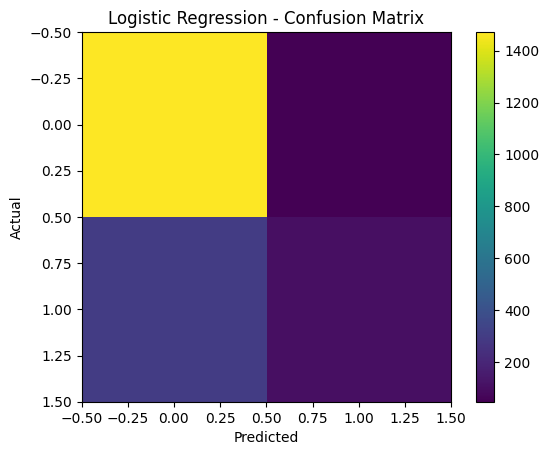

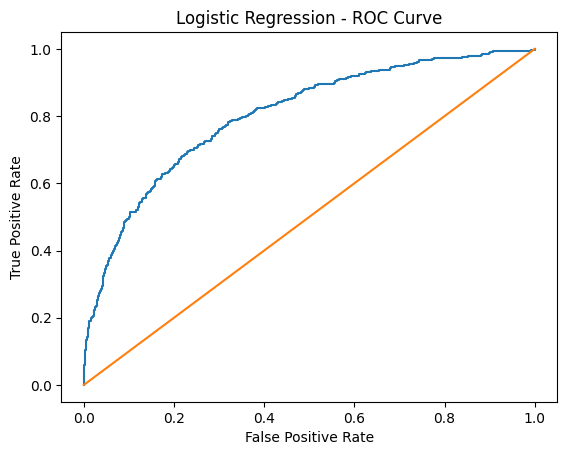

In [ ]:
log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train, y_train)

y_pred = log_clf.predict(X_test)
y_prob = log_clf.predict_proba(X_test)[:,1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure()
plt.imshow(cm)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("Logistic Regression - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


Decision Tree Results
Accuracy: 0.7757009345794392
Precision: 0.46973365617433416
Recall: 0.47665847665847666
F1 Score: 0.47317073170731705
ROC-AUC: 0.666242339053399
[[1300  219]
 [ 213  194]]


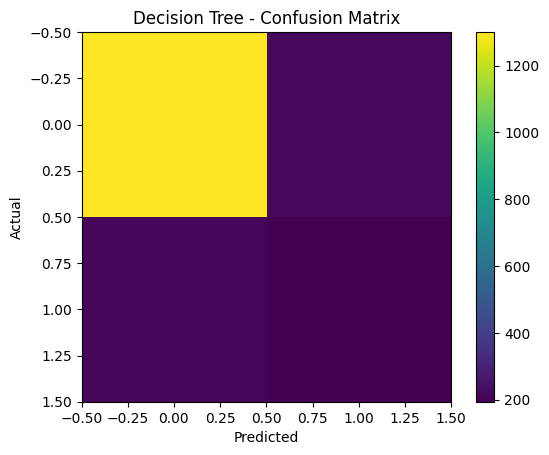

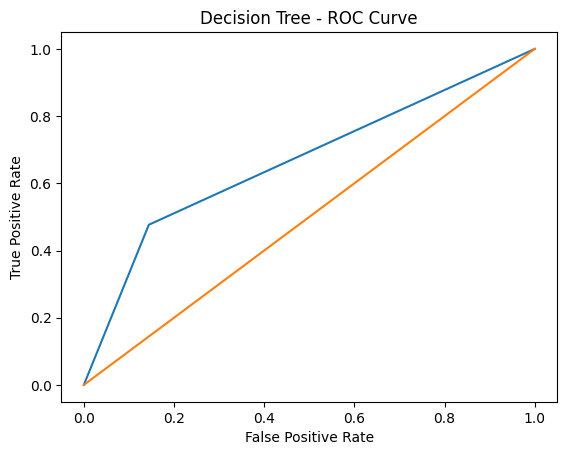

In [ ]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

y_pred = dt_clf.predict(X_test)
y_prob = dt_clf.predict_proba(X_test)[:,1]

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure()
plt.imshow(cm)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("Decision Tree - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


Random Forest Results
Accuracy: 0.8582554517133957
Precision: 0.8101851851851852
Recall: 0.42997542997543
F1 Score: 0.5617977528089888
ROC-AUC: 0.8532583993413486
[[1478   41]
 [ 232  175]]


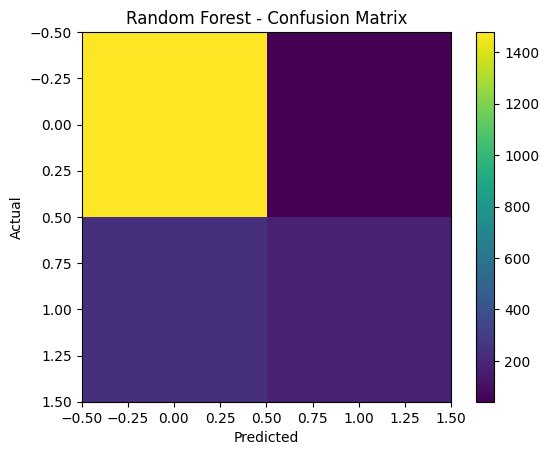

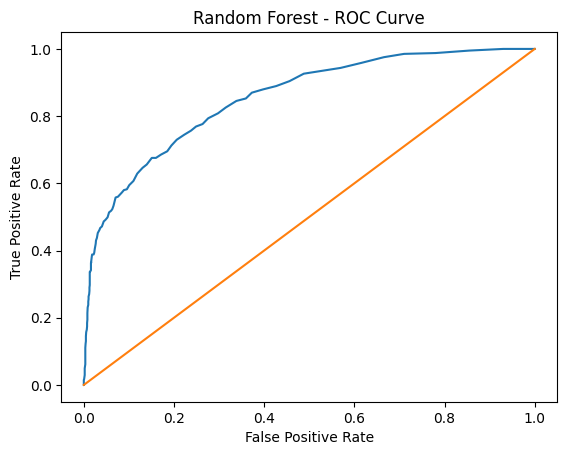

In [ ]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:,1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure()
plt.imshow(cm)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [ ]:
df_reg = df.copy()

X_reg = df_reg.drop("EstimatedSalary", axis=1)
y_reg = df_reg["EstimatedSalary"]

X_reg = pd.get_dummies(X_reg, columns=['Geography'], drop_first=True)

le = LabelEncoder()
X_reg['Gender'] = le.fit_transform(X_reg['Gender'])

scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)


Linear Regression Results
MAE: 48864.184284980984
MSE: 3222894106.420117
RMSE: 56770.53907107204
R2 Score: -0.001991248061450568


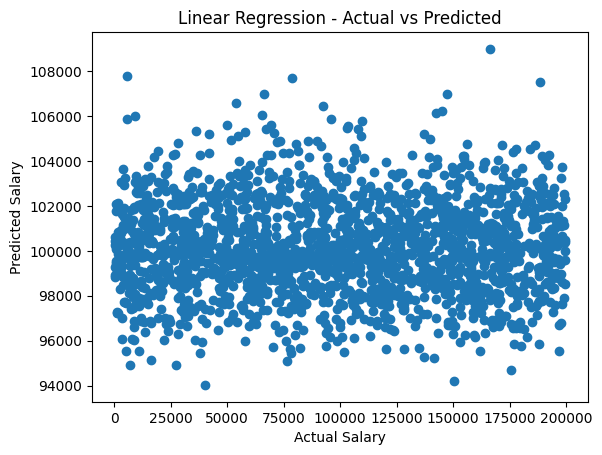

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)

y_pred = lin_reg.predict(X_test_r)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test_r, y_pred))
print("MSE:", mean_squared_error(y_test_r, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred)))
print("R2 Score:", r2_score(y_test_r, y_pred))

plt.figure()
plt.scatter(y_test_r, y_pred)
plt.title("Linear Regression - Actual vs Predicted")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()


Decision Tree Regressor Results
MAE: 66925.90080477673
MSE: 6774343949.023931
RMSE: 82306.40284342361
R2 Score: -1.1061298088443006


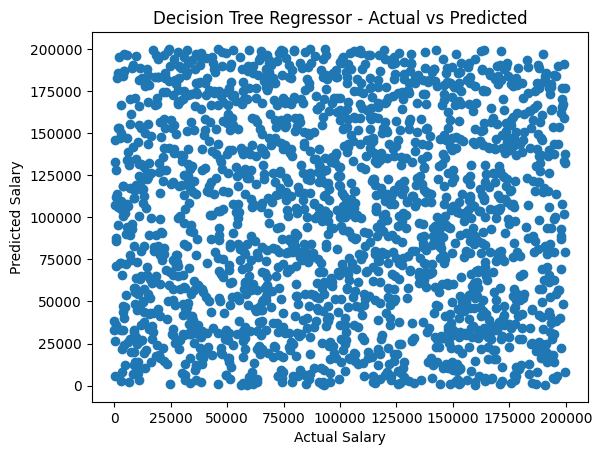

In [ ]:
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_r, y_train_r)

y_pred = dt_reg.predict(X_test_r)

print("Decision Tree Regressor Results")
print("MAE:", mean_absolute_error(y_test_r, y_pred))
print("MSE:", mean_squared_error(y_test_r, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred)))
print("R2 Score:", r2_score(y_test_r, y_pred))

plt.figure()
plt.scatter(y_test_r, y_pred)
plt.title("Decision Tree Regressor - Actual vs Predicted")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()


Random Forest Regressor Results
MAE: 50117.6550611388
MSE: 3463588715.5220294
RMSE: 58852.2617706578
R2 Score: -0.07682271438088728


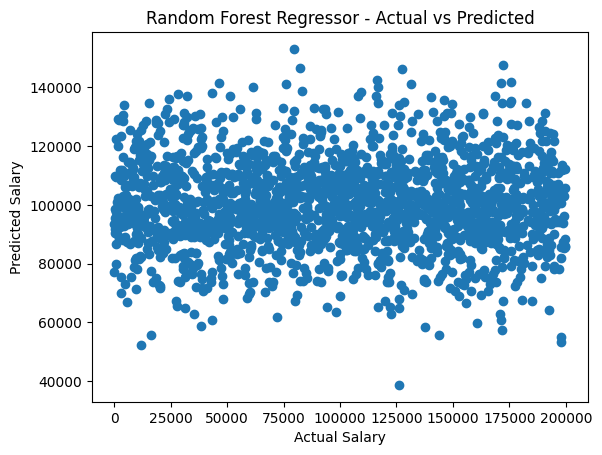

In [ ]:
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_r, y_train_r)

y_pred = rf_reg.predict(X_test_r)

print("Random Forest Regressor Results")
print("MAE:", mean_absolute_error(y_test_r, y_pred))
print("MSE:", mean_squared_error(y_test_r, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred)))
print("R2 Score:", r2_score(y_test_r, y_pred))

plt.figure()
plt.scatter(y_test_r, y_pred)
plt.title("Random Forest Regressor - Actual vs Predicted")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd


In [ ]:
log_clf = LogisticRegression(max_iter=1000)
dt_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

log_clf.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
models = {
    "Logistic Regression": log_clf,
    "Decision Tree": dt_clf,
    "Random Forest": rf_clf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1-Score","ROC-AUC"])
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.817757,0.684211,0.255528,0.372093,0.803039
1,Decision Tree,0.775701,0.469734,0.476658,0.473171,0.666242
2,Random Forest,0.858255,0.810185,0.429975,0.561798,0.853258


In [ ]:
hard_vote = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('dt', dt_clf),
        ('rf', rf_clf)
    ],
    voting='hard'
)

hard_vote.fit(X_train, y_train)

y_pred_hard = hard_vote.predict(X_test)

print("Hard Voting")
print("Accuracy:", accuracy_score(y_test, y_pred_hard))
print("Precision:", precision_score(y_test, y_pred_hard))
print("Recall:", recall_score(y_test, y_pred_hard))
print("F1 Score:", f1_score(y_test, y_pred_hard))

cm = confusion_matrix(y_test, y_pred_hard)
print("Confusion Matrix:")
print(cm)


Hard Voting
Accuracy: 0.8515057113187954
Precision: 0.7951219512195122
Recall: 0.4004914004914005
F1 Score: 0.5326797385620915
Confusion Matrix:
[[1477   42]
 [ 244  163]]


In [ ]:
soft_vote = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('dt', dt_clf),
        ('rf', rf_clf)
    ],
    voting='soft'
)

soft_vote.fit(X_train, y_train)

y_pred_soft = soft_vote.predict(X_test)
y_prob_soft = soft_vote.predict_proba(X_test)[:,1]

print("Soft Voting")
print("Accuracy:", accuracy_score(y_test, y_pred_soft))
print("Precision:", precision_score(y_test, y_pred_soft))
print("Recall:", recall_score(y_test, y_pred_soft))
print("F1 Score:", f1_score(y_test, y_pred_soft))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_soft))

cm = confusion_matrix(y_test, y_pred_soft)
print("Confusion Matrix:")
print(cm)

Soft Voting
Accuracy: 0.833852544132918
Precision: 0.6548042704626335
Recall: 0.4520884520884521
F1 Score: 0.5348837209302325
ROC-AUC: 0.8301109775764154
Confusion Matrix:
[[1422   97]
 [ 223  184]]


In [ ]:
results.append([
    "Hard Voting",
    accuracy_score(y_test, y_pred_hard),
    precision_score(y_test, y_pred_hard),
    recall_score(y_test, y_pred_hard),
    f1_score(y_test, y_pred_hard),
    "-"
])

results.append([
    "Soft Voting",
    accuracy_score(y_test, y_pred_soft),
    precision_score(y_test, y_pred_soft),
    recall_score(y_test, y_pred_soft),
    f1_score(y_test, y_pred_soft),
    roc_auc_score(y_test, y_prob_soft)
])

final_results = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1-Score","ROC-AUC"])
final_results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.817757,0.684211,0.255528,0.372093,0.803039
1,Decision Tree,0.775701,0.469734,0.476658,0.473171,0.666242
2,Random Forest,0.858255,0.810185,0.429975,0.561798,0.853258
3,Hard Voting,0.851506,0.795122,0.400491,0.532680,-
4,Soft Voting,0.833853,0.654804,0.452088,0.534884,0.830111
